In [1]:
import sqlite3

conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

cursor.execute('''CREATE TABLE IF NOT EXISTS SALES(
                  id INT PRIMARY KEY,
                  product TEXT,
                  quantity INTEGER,
                  price REAL)''')

conn.commit()
conn.close()

In [5]:
import sqlite3

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

cursor.executemany('''INSERT INTO SALES(product,quantity,price) VALUES(?,?,?)''',
               [('Product A', 10, 15.50),
                ('Product B', 5, 25.00),
                ('Product A', 20, 15.50),
                ('Product C', 15, 30.00),
                ('Product B', 7, 25.00) ])
conn.commit()
conn.close()

In [9]:
import sqlite3
import pandas as pd 

conn = sqlite3.connect('sales_data.db')
query = ''' SELECT product,SUM(quantity) as total_qty,SUM(quantity * price) as revenue
            FROM sales
            GROUP BY product'''

df=pd.read_sql_query(query,conn)
conn.close()

print(df)

     product  total_qty  revenue
0  Product A         30    465.0
1  Product B         12    300.0
2  Product C         15    450.0


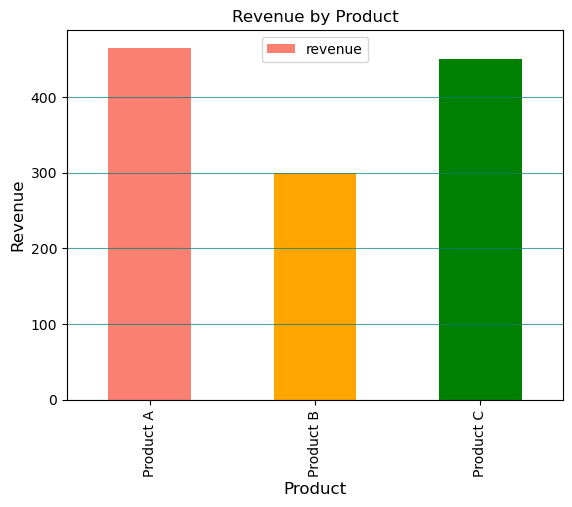

In [51]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='product', y='revenue',color = ['salmon', 'orange', 'green'])

plt.xlabel('Product',fontsize = 12)
plt.ylabel('Revenue',fontsize = 12)
plt.title('Revenue by Product')
plt.grid(axis='y', linestyle='-', alpha=0.7, color = 'teal')

plt.savefig("C:/Users/Vinit/Downloads/sales_chart.png")
plt.show()

# Task Done 

In [55]:
import sqlite3

conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

conn.execute('''ALTER TABLE SALES
                ADD COLUMN sales_date TEXT''')

conn.commit()
conn.close()

In [61]:
import sqlite3

conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

conn.executemany('''UPDATE SALES SET sales_date = ? WHERE product = ? ''',
                 [ ('2025-04-20', 'Product A'),
                   ('2025-04-21', 'Product B'),
                   ('2025-04-20', 'Product A'),
                   ('2025-04-19', 'Product C'),
                   ('2025-04-21', 'Product B') ] )
conn.commit()
conn.close()

# FILTERING DATA BY DATE RANGE

In [65]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('sales_data.db')

query = (''' SELECT product,SUM(quantity) AS total_qty, SUM(quantity * price) AS revenue
             FROM SALES
             WHERE sales_date BETWEEN '2025-04-20' AND '2025-04-21'
             GROUP BY product''')
df = pd.read_sql_query(query,conn)
conn.close()
print(df)

     product  total_qty  revenue
0  Product A         30    465.0
1  Product B         12    300.0


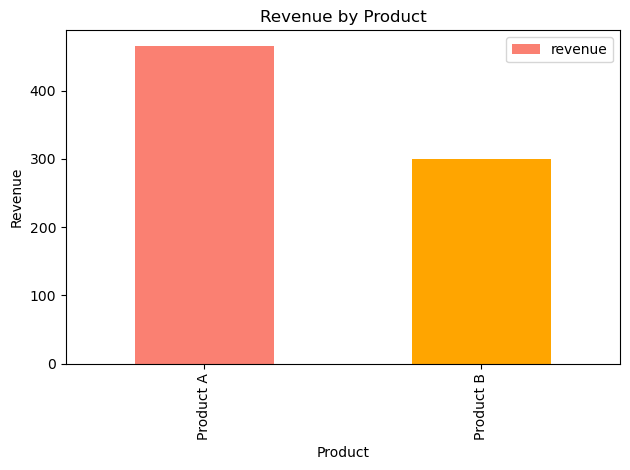

In [70]:
import matplotlib.pyplot as plt
df.plot(kind='bar', x='product', y='revenue', color=['salmon', 'orange', 'green'])
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Revenue by Product")
plt.tight_layout()
plt.savefig("C:/Users/Vinit/Downloads/sales_chart2.png")
plt.show()

 # SQL Query to Find Product with Highest Revenue

In [73]:
import sqlite3

conn = sqlite3.connect('sales_data.db')

query = ('''SELECT product,SUM(quantity) AS total_qty, SUM(quantity * price) AS revenue
             FROM SALES
             GROUP BY product
             ORDER BY product DESC
             LIMIT 1''')

df = pd.read_sql_query(query,conn)

conn.close()
print(df)

     product  total_qty  revenue
0  Product C         15    450.0


     month  monthly_revenue
0  2025-04            280.0
1  2025-05            760.0
2  2025-06            175.0


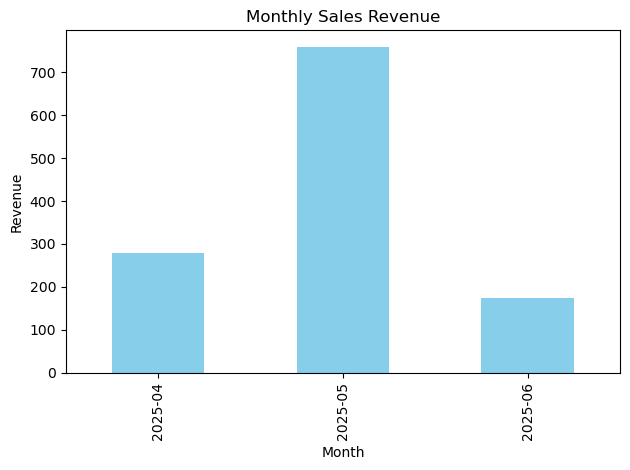

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales_data.db")

query = '''SELECT strftime('%Y-%m', sales_date) AS month,SUM(quantity * price) AS monthly_revenue
           FROM sales
           GROUP BY month
           ORDER BY month'''

monthly_df = pd.read_sql_query(query, conn)

conn.close()

print(monthly_df)


monthly_df.plot(kind='bar', x='month', y='monthly_revenue', legend=False, color='skyblue')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Sales Revenue")
plt.tight_layout()
plt.show()


   sales_date  daily_revenue
0  2025-04-20          155.0
1  2025-04-21          125.0
2  2025-05-01          310.0
3  2025-05-05          450.0
4  2025-06-10          175.0


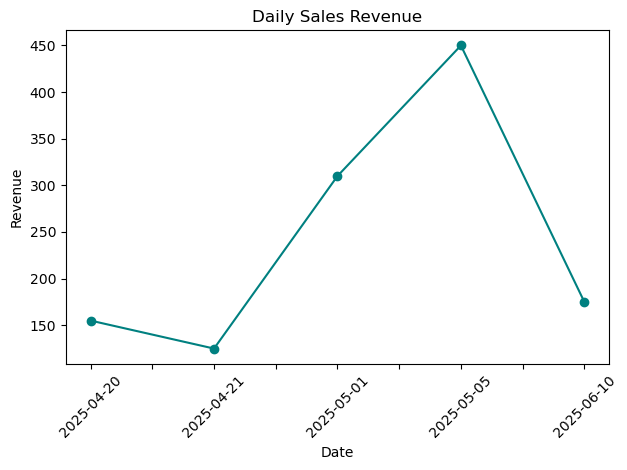

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales_data.db")

query = '''
SELECT 
    sales_date,
    SUM(quantity * price) AS daily_revenue
FROM sales
GROUP BY sales_date
ORDER BY sales_date
'''

daily_df = pd.read_sql_query(query, conn)
conn.close()

print(daily_df)

daily_df.plot(kind='line', x='sales_date', y='daily_revenue', marker='o', color='teal', legend = False)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Daily Sales Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
